# 05. Multilayer Perceptron (MLP): Scikit-Learn and PyTorch
**Algorithm Covered:**
- **Multilayer Perceptron (Feedforward Deep Artificial Neural Network)**

**Implementations:**
1. **Scikit-Learn MLPClassifier**: High-level production API with early stopping and loss curves
2. **PyTorch Custom Deep MLP**: Modular neural network with Linear layers, Batch Normalization, Dropout regularization, ReLU activations, CrossEntropyLoss, and Adam optimizer

**Dataset:** MNIST Handwritten Digits Dataset (1,797 samples, 8x8 pixel images, 64 features, 10 classes)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

torch.manual_seed(42)
np.random.seed(42)
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation Device: {device}")


PyTorch version: 2.14.0+cpu
Computation Device: cpu


## 1. Dataset Exploration and Visualization
The Digits dataset comprises 1,797 normalized $8 \times 8$ grayscale images of numerical digits (0 through 9).


Dataset Shape: (1797, 64), Target Classes: [0 1 2 3 4 5 6 7 8 9]


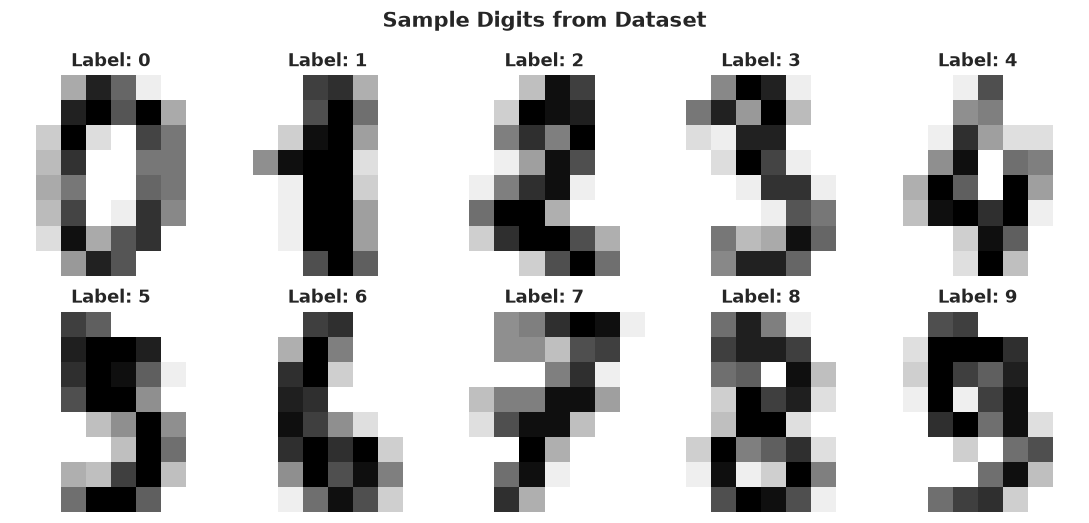

In [2]:
digits = load_digits()
X_raw = digits.data
y = digits.target

print(f"Dataset Shape: {X_raw.shape}, Target Classes: {np.unique(y)}")

# Visualize sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary')
    ax.set_title(f"Label: {digits.target[i]}", fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle("Sample Digits from Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [3]:
# Train-Validation-Test Split (70% Train, 15% Val, 15% Test)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_raw, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples:   {X_train_scaled.shape[0]}")
print(f"Validation samples: {X_val_scaled.shape[0]}")
print(f"Test samples:       {X_test_scaled.shape[0]}")


Training samples:   1257
Validation samples: 270
Test samples:       270


## 2. Part 1: Scikit-Learn MLPClassifier
### Mathematical Formulation
A Multilayer Perceptron maps input vector $x \in \mathbb{R}^d$ through $L$ hidden layers:
$$a^{(1)} = \sigma(W^{(1)} x + b^{(1)})$$
$$a^{(l)} = \sigma(W^{(l)} a^{(l-1)} + b^{(l)}), \quad l = 2, \dots, L$$
$$\hat{y} = \text{softmax}(W^{(L+1)} a^{(L)} + b^{(L+1)})$$
Weights are optimized by minimizing categorical Cross-Entropy Loss:
$$\mathcal{L} = -\sum_{i=1}^N \sum_{k=1}^K y_{ik} \ln \hat{y}_{ik} + \frac{\alpha}{2} \sum_{l} \|W^{(l)}\|_F^2$$
via backpropagation (chain rule of calculus) with Adam or SGD.


Scikit-Learn MLP Test Accuracy: 0.9630
Converged after 15 iterations


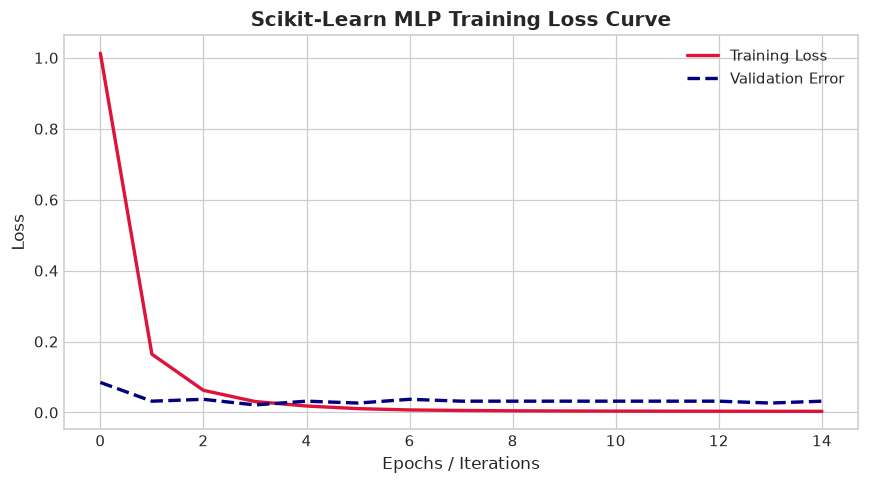

In [4]:
mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    learning_rate_init=0.005,
    max_iter=150,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)

mlp_sklearn.fit(X_train_scaled, y_train)

y_pred_sk = mlp_sklearn.predict(X_test_scaled)
acc_sk = accuracy_score(y_test, y_pred_sk)

print(f"Scikit-Learn MLP Test Accuracy: {acc_sk:.4f}")
print(f"Converged after {mlp_sklearn.n_iter_} iterations")

# Plotting Scikit-Learn Loss Curve
plt.figure(figsize=(8, 4.5))
plt.plot(mlp_sklearn.loss_curve_, color='crimson', lw=2.2, label='Training Loss')
if hasattr(mlp_sklearn, 'validation_scores_'):
    plt.plot([1 - s for s in mlp_sklearn.validation_scores_], color='navy', lw=2.2, linestyle='--', label='Validation Error')
plt.title("Scikit-Learn MLP Training Loss Curve", fontsize=13, fontweight='bold')
plt.xlabel("Epochs / Iterations", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Part 2: Custom PyTorch Deep MLP
Here we build a production-grade PyTorch `nn.Module` featuring:
- **Input Dimension:** 64 (8x8 pixel features)
- **Hidden Layer 1:** 128 units + Batch Normalization + ReLU + Dropout (0.25)
- **Hidden Layer 2:** 64 units + Batch Normalization + ReLU + Dropout (0.20)
- **Output Layer:** 10 logits (corresponding to classes 0 through 9)
- **Loss Function:** `nn.CrossEntropyLoss()`
- **Optimizer:** `optim.Adam(lr=0.003, weight_decay=1e-4)`


In [5]:
# Convert data to PyTorch Tensors and DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset   = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32),   torch.tensor(y_val, dtype=torch.long))
test_dataset  = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32),  torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

class DeepMLP(nn.Module):
    def __init__(self, in_features=64, num_classes=10):
        super(DeepMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),
            
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

model = DeepMLP().to(device)
print(model)


DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [6]:
# Training Loop with Epoch-by-Epoch Validation Tracking
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

epochs = 50
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    
    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    scheduler.step(epoch_val_loss)
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")


Epoch [01/50] Train Loss: 1.1992 | Train Acc: 0.7327 || Val Loss: 0.4583 | Val Acc: 0.9111


Epoch [10/50] Train Loss: 0.0718 | Train Acc: 0.9793 || Val Loss: 0.0717 | Val Acc: 0.9667


Epoch [20/50] Train Loss: 0.0392 | Train Acc: 0.9889 || Val Loss: 0.0410 | Val Acc: 0.9852


Epoch [30/50] Train Loss: 0.0186 | Train Acc: 0.9936 || Val Loss: 0.0397 | Val Acc: 0.9852


Epoch [40/50] Train Loss: 0.0321 | Train Acc: 0.9905 || Val Loss: 0.0409 | Val Acc: 0.9815


Epoch [50/50] Train Loss: 0.0117 | Train Acc: 0.9984 || Val Loss: 0.0317 | Val Acc: 0.9889


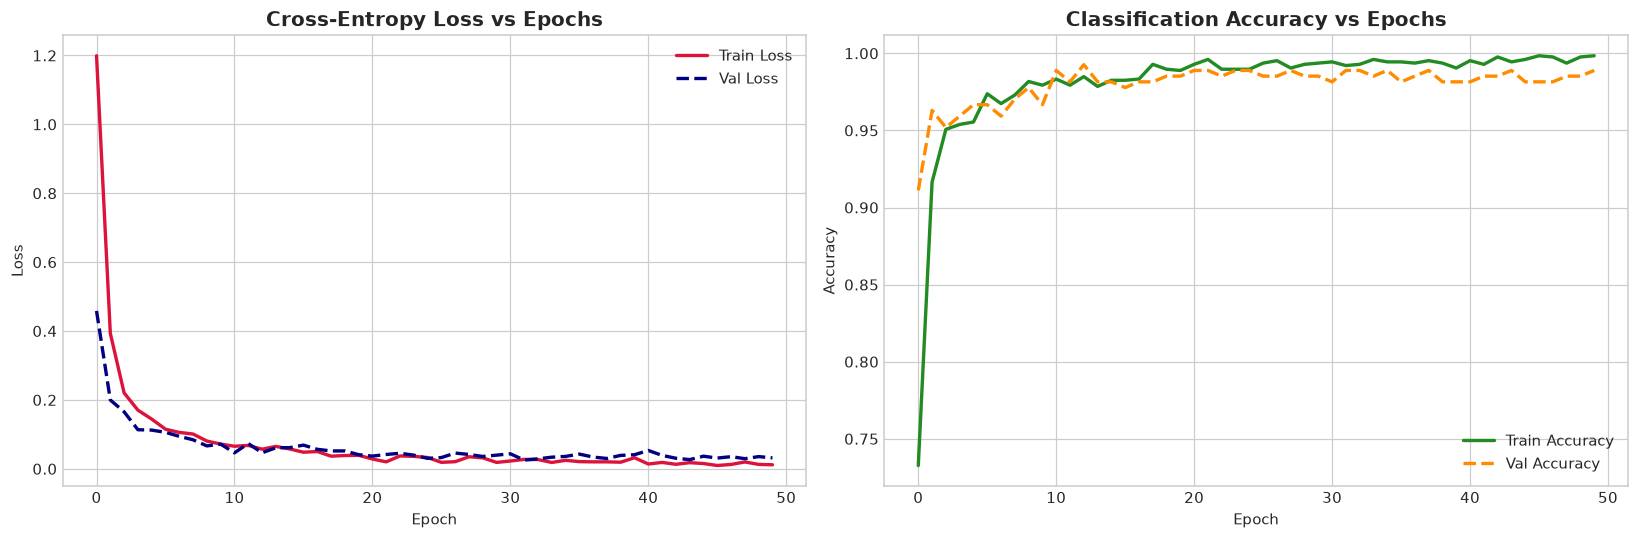

In [7]:
# Plotting PyTorch Loss and Accuracy Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Curves
ax1.plot(history['train_loss'], label='Train Loss', color='crimson', lw=2.2)
ax1.plot(history['val_loss'], label='Val Loss', color='navy', lw=2.2, linestyle='--')
ax1.set_title("Cross-Entropy Loss vs Epochs", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Accuracy Curves
ax2.plot(history['train_acc'], label='Train Accuracy', color='forestgreen', lw=2.2)
ax2.plot(history['val_acc'], label='Val Accuracy', color='darkorange', lw=2.2, linestyle='--')
ax2.set_title("Classification Accuracy vs Epochs", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()


In [8]:
# Final Evaluation on Held-Out Test Set
model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.numpy())

acc_pytorch = accuracy_score(test_targets, test_preds)
print(f"PyTorch Deep MLP Test Accuracy: {acc_pytorch:.4f}\n")
print("Detailed Classification Report:")
print(classification_report(test_targets, test_preds, digits=4))


PyTorch Deep MLP Test Accuracy: 0.9889

Detailed Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        27
           1     0.9286    0.9630    0.9455        27
           2     1.0000    1.0000    1.0000        27
           3     1.0000    1.0000    1.0000        28
           4     0.9643    1.0000    0.9818        27
           5     1.0000    1.0000    1.0000        27
           6     1.0000    1.0000    1.0000        27
           7     1.0000    1.0000    1.0000        27
           8     1.0000    0.9231    0.9600        26
           9     1.0000    1.0000    1.0000        27

    accuracy                         0.9889       270
   macro avg     0.9893    0.9886    0.9887       270
weighted avg     0.9893    0.9889    0.9889       270



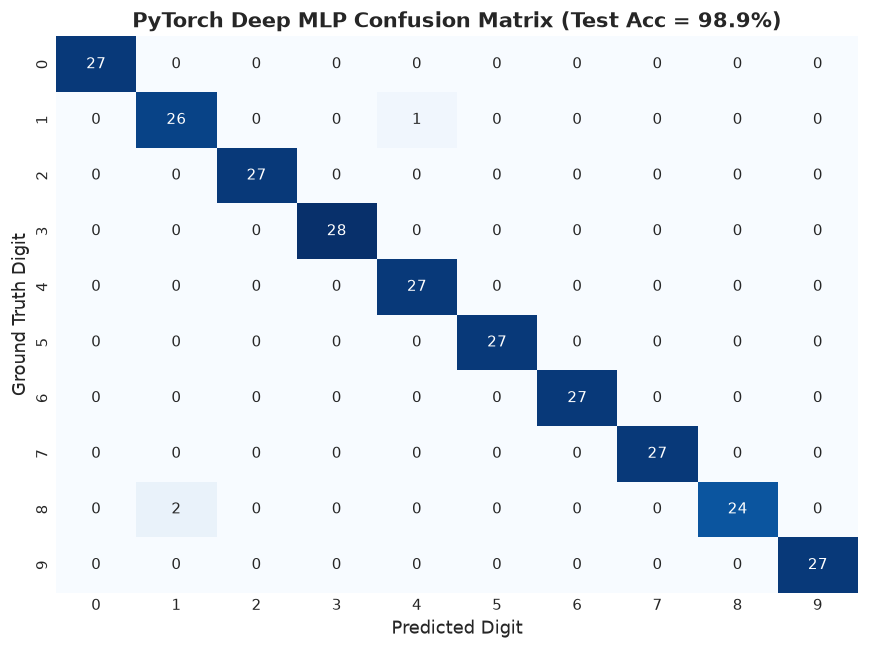

In [9]:
# Confusion Matrix Heatmap
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.title(f"PyTorch Deep MLP Confusion Matrix (Test Acc = {acc_pytorch*100:.1f}%)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Digit", fontsize=12)
plt.ylabel("Ground Truth Digit", fontsize=12)
plt.tight_layout()
plt.show()


## 4. Visualizing Model Predictions
Let's inspect sample test images alongside their predicted class probabilities.


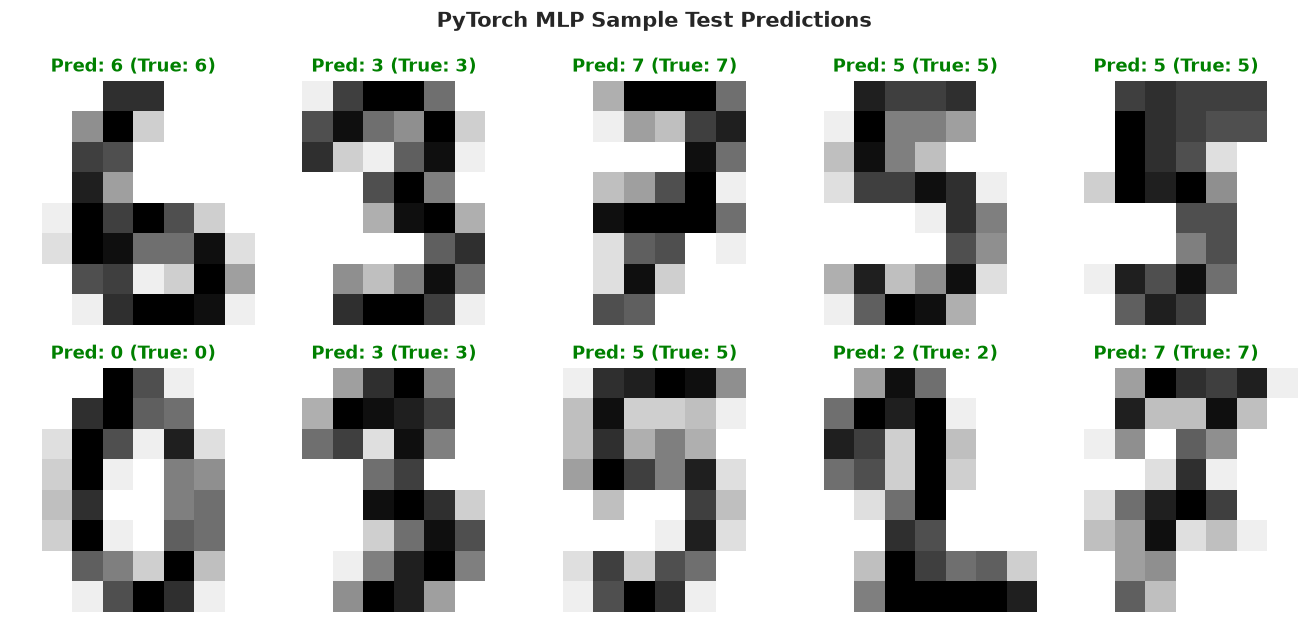

In [10]:
# Sample predictions visualization
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = scaler.inverse_transform(X_test_scaled[i].reshape(1, -1)).reshape(8, 8)
    true_label = test_targets[i]
    pred_label = test_preds[i]
    
    ax.imshow(img, cmap='binary')
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"Pred: {pred_label} (True: {true_label})", color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle("PyTorch MLP Sample Test Predictions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Summary: Scikit-Learn vs PyTorch MLP
| Dimension | Scikit-Learn `MLPClassifier` | PyTorch Custom `nn.Module` |
| :--- | :--- | :--- |
| **Setup Overhead** | Extremely minimal (single line `fit`) | Explicit tensor/dataset/loader boilerplate |
| **Architectural Flexibility** | Fixed forward feedforward structure | Arbitrary connections, skip connections, custom loss |
| **Hardware Acceleration** | CPU only | GPU / CUDA / MPS acceleration |
| **Regularization Options** | $L_2$ weight penalty (`alpha`) | Dropout, BatchNorm, LayerNorm, custom regularizers |
| **Production Best Use** | Rapid baseline tabular ML | Deep learning, vision, NLP, custom training loops |
